# 2D complementarity maps

Project the TCR-peptide-MHC interface (CDR1-3, peptide, MHC groove helices/floor) onto the
canonical groove plane, build the two canonical polars tables (residue markup + contacts), and
render a metadata-rich SVG complementarity map.

In [1]:
# Environment versions (reproducibility)
import sys, polars as pl, tcren
print('python', sys.version.split()[0], '| polars', pl.__version__, '| tcren', tcren.__version__)

python 3.11.15 | polars 1.41.2 | tcren 2.1.2


In [2]:
# Load a native complex, type chains (arda) and annotate the MHC groove
from tcren.structure import parse_structure
from tcren.annotation import classify_chains
from tcren.mhc import annotate_mhc

structure = parse_structure('data/Native2026/1ao7.pdb.gz', pdb_id='1ao7')
classify_chains(structure, organism='human')
annotate_mhc(structure)
[(c.chain_id, c.chain_type) for c in structure.chains]

[('A', 'TRA'), ('B', 'TRB'), ('C', 'PEPTIDE'), ('D', 'MHCa'), ('E', 'B2M')]

In [3]:
# Project onto the canonical groove plane and build the canonical tables
from tcren.project2d import (project_structure, residue_markup_table,
                             contacts_table, ca_contacts_table, pocket_markers)

projection = project_structure(structure)
markup = residue_markup_table(structure, projection)
contacts = contacts_table(structure, threshold=5.0)
ca_contacts = ca_contacts_table(structure, threshold=8.0)
pockets = pocket_markers(markup)
markup.head()

structure_id,structure_chain,complex_chain,complex_region,residue_index,aa_index,aa_len,aa,x,y,z,u,v,height
str,str,str,str,i64,i64,i64,str,f64,f64,f64,f64,f64,f64
"""1ao7""","""A""","""tra""","""fr1""",1,0,110,"""K""",null,null,null,null,null,null
"""1ao7""","""A""","""tra""","""fr1""",2,1,110,"""E""",null,null,null,null,null,null
"""1ao7""","""A""","""tra""","""fr1""",3,2,110,"""V""",null,null,null,null,null,null
"""1ao7""","""A""","""tra""","""fr1""",4,3,110,"""E""",null,null,null,null,null,null
"""1ao7""","""A""","""tra""","""fr1""",5,4,110,"""Q""",null,null,null,null,null,null


In [4]:
# Contacts table is compatible with the original TCRen 5 A calculation
contacts.head()

structure_id,structure_chain_1,structure_chain_2,residue_index_1,residue_index_2,aa_index_1,aa_index_2,min_dist,contact_type,backbone_1,backbone_2
str,str,str,i64,i64,i64,i64,f64,str,bool,bool
"""1ao7""","""D""","""E""",235,10,234,9,2.447153,"""hydrogen_bond""",true,false
"""1ao7""","""A""","""C""",31,5,30,4,2.54217,"""hydrogen_bond""",false,false
"""1ao7""","""C""","""D""",1,171,0,170,2.631378,"""hydrogen_bond""",true,false
"""1ao7""","""A""","""B""",50,105,49,100,2.63158,"""hydrogen_bond""",false,false
"""1ao7""","""A""","""B""",35,106,34,101,2.647912,"""hydrogen_bond""",false,true


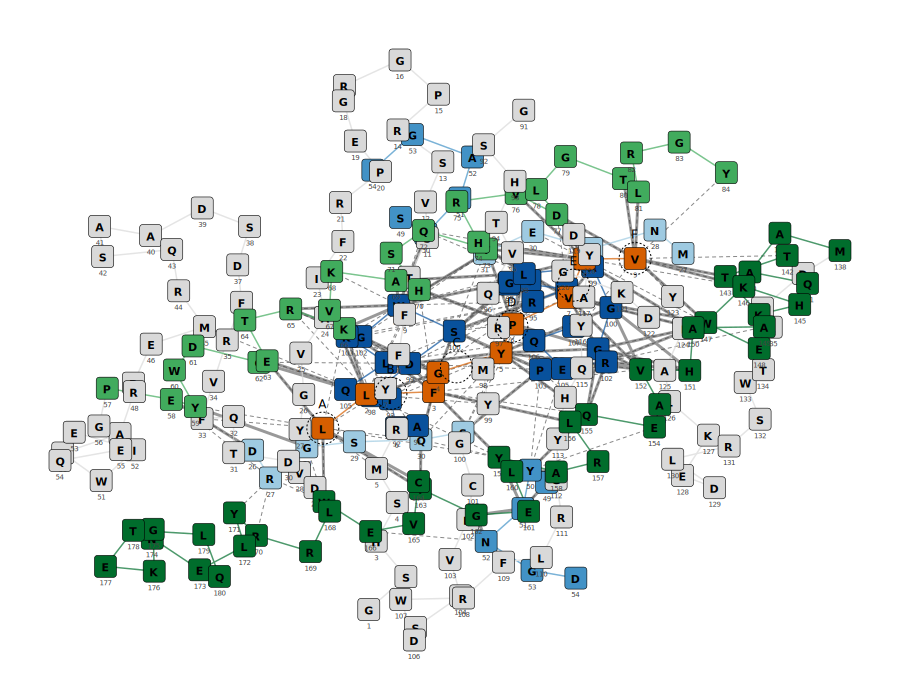

In [5]:
# Render the SVG complementarity map (squares=residues, bold=Ca-Ca, dashed=inter-residue)
from tcren.viz import render_complementarity_map
from IPython.display import SVG

svg = render_complementarity_map(markup, contacts=contacts, ca_contacts=ca_contacts, pockets=pockets)
SVG(svg)

## Multiple views of the same complex

The full map above shows the whole interface. Below are **focused complementarity-map views**
(chain subsets — the TCR↔peptide footprint, and the peptide sitting in the MHC groove) followed
by **three orthogonal structural views** of the oriented complex. Contacts in every view are the
same closest-atom edges read off the contact table.

TCR (CDR1-3) ↔ peptide


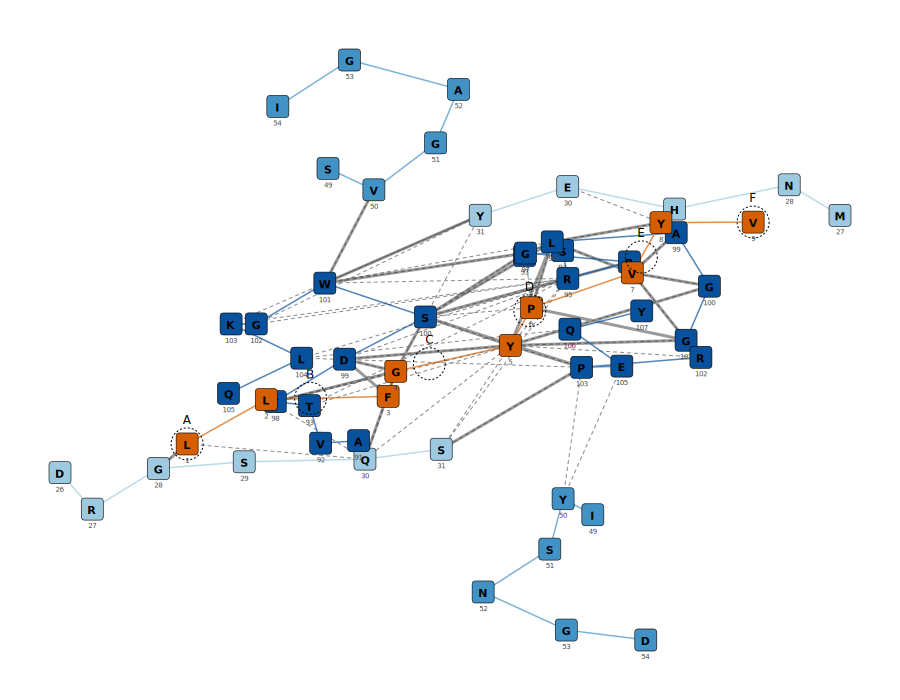

peptide in the MHC groove


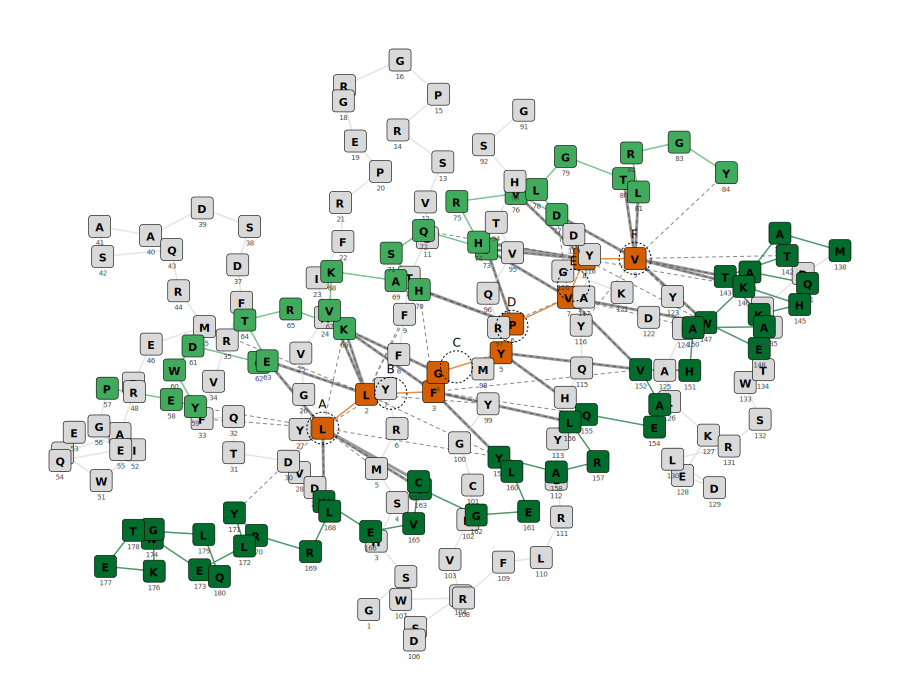

In [6]:
# Different complementarity-map VIEWS via chain subsets (edges = contacts read off the map).
from IPython.display import display
map_views = {'TCR (CDR1-3) ↔ peptide': ['tra', 'trb', 'peptide'],
             'peptide in the MHC groove': ['peptide', 'mhca', 'mhcb']}
for title, chains in map_views.items():
    print(title)
    display(SVG(render_complementarity_map(
        markup, contacts=contacts, ca_contacts=ca_contacts, pockets=pockets, show_chains=chains)))

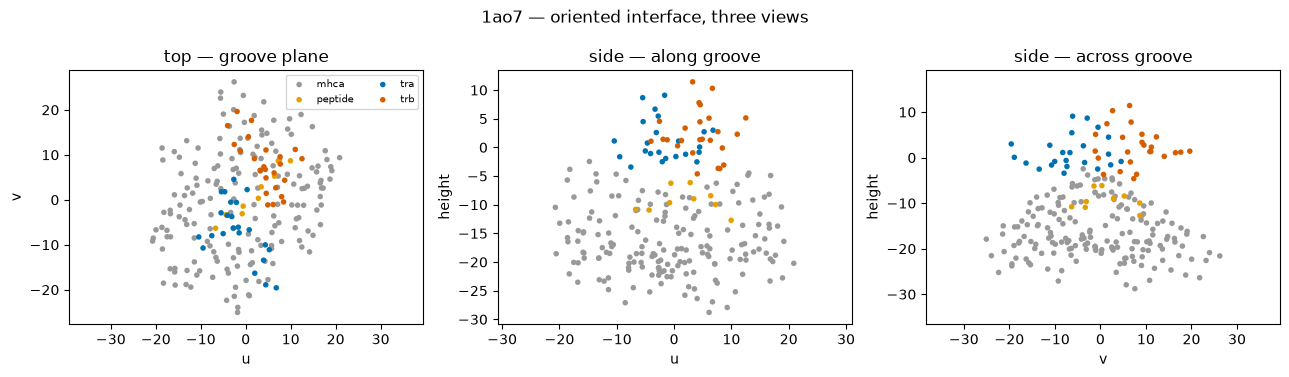

In [7]:
# Different STRUCTURAL views: the oriented interface in 3 orthogonal planes.
# u = along the groove (peptide N->C), v = across the groove, height = MHC->TCR normal.
# The canonical frame puts the TCR on top (+height) of the peptide/MHC.
import matplotlib.pyplot as plt
m = markup.filter(pl.col('u').is_not_null())
chain_col = {'mhca': '#999999', 'mhcb': '#777777', 'peptide': '#E69F00',
             'tra': '#0072B2', 'trb': '#D55E00'}
planes = [('u', 'v', 'top — groove plane'),
          ('u', 'height', 'side — along groove'),
          ('v', 'height', 'side — across groove')]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, (a1, a2, ttl) in zip(axes, planes):
    for ch, col in chain_col.items():
        sub = m.filter(pl.col('complex_chain') == ch)
        if sub.height:
            ax.scatter(sub[a1], sub[a2], s=16, c=col, label=ch, edgecolor='none')
    ax.set_xlabel(a1); ax.set_ylabel(a2); ax.set_title(ttl); ax.set_aspect('equal', 'datalim')
axes[0].legend(fontsize=7, ncol=2, loc='best')
fig.suptitle('1ao7 — oriented interface, three views'); plt.tight_layout(); plt.show()

In [8]:
# Polars summarize: contact-type breakdown of the TCR (CDR) -> peptide interface
tcr_pep = (contacts
    .join(markup.select('structure_chain', 'aa_index', 'complex_chain', 'complex_region'),
          left_on=['structure_chain_1', 'aa_index_1'],
          right_on=['structure_chain', 'aa_index'])
    .filter(pl.col('complex_chain').is_in(['tra', 'trb'])
            & pl.col('structure_chain_2').is_in([c.chain_id for c in structure.chains if c.chain_type=='PEPTIDE'])))
tcr_pep.group_by('complex_region', 'contact_type').agg(
    pl.len().alias('n'), pl.col('min_dist').min().round(2).alias('closest')
).sort('complex_region', 'n', descending=[False, True])

complex_region,contact_type,n,closest
str,str,u32,f64
"""cdr1""","""hydrogen_bond""",4,2.54
"""cdr1""","""polar""",3,3.66
"""cdr1""","""hydrophobic""",1,4.93
"""cdr3""","""polar""",13,3.32
"""cdr3""","""hydrogen_bond""",4,2.89
"""cdr3""","""hydrophobic""",4,3.66
